In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [1]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.9 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!pip install roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.4 MB/s eta 0:00:00


In [10]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="OhgSvzzHt71Rqg33OzS9")
project = rf.workspace("yolo-project-0sfck").project("helmet-detection-ligfk")
version = project.version(4)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Helmet-Detection-4 in yolov8:: 100%|██████████| 1138/1138 [00:00<00:00, 7920.11it/s]


In [11]:
!ls

Helmet-Detection-4  sample_data


In [12]:
!find . -name "data.yaml"

./Helmet-Detection-4/data.yaml


In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [15]:
model.train(
    data="./Helmet-Detection-4/data.yaml",
    epochs=10,
    imgsz=640
)

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./Helmet-Detection-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cdd32273830>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [16]:
!ls runs/detect/train/weights

In [19]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-2/weights/best.pt")

In [20]:
from google.colab import files

uploaded = files.upload()

Saving helmetyolo.png to helmetyolo.png


In [21]:
results = model.predict(
    source="helmetyolo.png",
    conf=0.25,
    save=True
)


image 1/1 /content/helmetyolo.png: 448x640 2 Helmets, 42.6ms
Speed: 2.4ms preprocess, 42.6ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


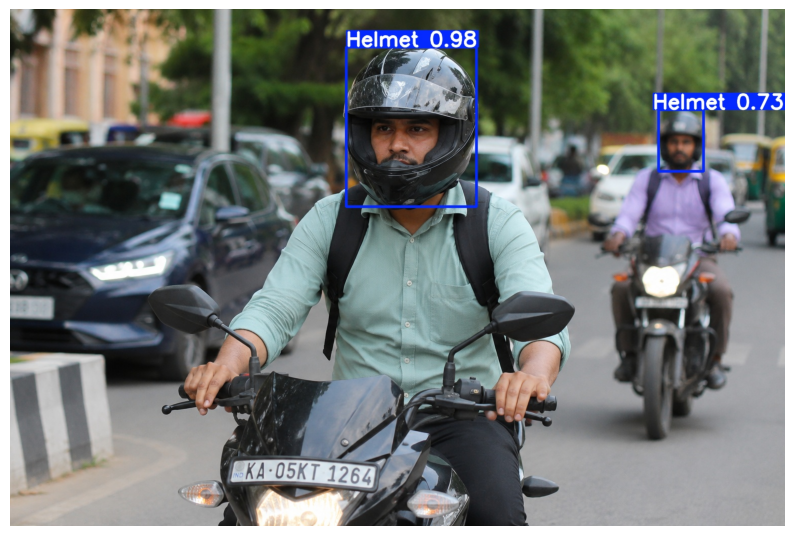

In [25]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/predict/helmetyolo.jpg")

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [26]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [18]:
!ls runs/detect

train  train-2


In [23]:
!find runs -type f | grep -E "jpg|jpeg|png"

runs/detect/predict/helmetyolo.jpg
runs/detect/train-2/labels.jpg
runs/detect/train-2/confusion_matrix.png
runs/detect/train-2/val_batch1_labels.jpg
runs/detect/train-2/confusion_matrix_normalized.png
runs/detect/train-2/val_batch0_labels.jpg
runs/detect/train-2/val_batch0_pred.jpg
runs/detect/train-2/BoxP_curve.png
runs/detect/train-2/results.png
runs/detect/train-2/val_batch1_pred.jpg
runs/detect/train-2/train_batch0.jpg
runs/detect/train-2/train_batch2.jpg
runs/detect/train-2/BoxPR_curve.png
runs/detect/train-2/BoxR_curve.png
runs/detect/train-2/train_batch1.jpg
runs/detect/train-2/BoxF1_curve.png


In [24]:
!ls runs/detect

predict  train	train-2
